In [1]:
import os
import yaml
import glob
import eurocropsml
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
BIN_SIZES = (5, 10, 15)
THRESHOLDS = (0.80, 0.90)

def summarize_country(pattern, label=None, show=True):
    label = label or pattern.removesuffix("*.npz")
    files = sorted(glob.glob(pattern))
    n_files = len(files)
    if n_files == 0:
        raise FileNotFoundError(f"No files match {pattern!r}")
    print(f"Found {n_files} {label} files")

    dates_per_file = []
    for f in tqdm(files, desc=f"Reading {label}", unit="file"):
        with np.load(f) as z:  # allow_pickle only if "dates" is an object array
            dates_per_file.append(z["dates"])

    # lengths = np.array([len(d) for d in dates_per_file]?
    lengths = np.fromiter((len(d) for d in dates_per_file), dtype=int, count=n_files) #more optimized
    all_dates = np.concatenate(dates_per_file)
    file_idx = np.repeat(np.arange(n_files), lengths)

    origin = all_dates.min()
    offsets = (all_dates - origin).astype(int)
    n_days = offsets.max() + 1

    # Date histogram
    unique_dates, date_counts = np.unique(all_dates, return_counts=True)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(unique_dates, date_counts)
    ax.set(title=f"Histogram of available dates ({label} files)",
           xlabel="Date", ylabel="Count")
    fig.tight_layout()
    plt.show() if show else plt.close(fig)

    results = {}
    for size in BIN_SIZES:
        #n_bins = (n_days + size - 1) // size
        n_bins = -(-n_days // size) #better

        # presence[i, b] = file i has >=1 date in bin b
        presence = np.zeros((n_files, n_bins), dtype=bool)
        presence[file_idx, offsets // size] = True
        counts = presence.sum(axis=0)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.bar(np.arange(n_bins), counts)
        for t in THRESHOLDS:
            ax.axhline(t * n_files, ls="--",
                       label=f"{int(t*100)}% ({t*n_files:.1f} files)")
        ax.set(title=f"{label}: files with ≥1 date per {size}-day group",
               xlabel=f"{size}-day group index (from {origin})",
               ylabel="Number of files")
        ax.legend()
        fig.tight_layout()
        plt.show() if show else plt.close(fig)

        for t in THRESHOLDS:
            kept_bins = (counts >= t * n_files)
            n_kept = int(presence[:, kept_bins].all(axis=1).sum()) #if kept_bins.any() else 0
            results[(size, t)] = n_kept
            print(f"[{label}] {size}-day, ≥{int(t*100)}%: "
                  f"{kept_bins.sum()} bins kept, {n_kept}/{n_files} files kept")

    return {"n_files": n_files, "all_dates": all_dates, "results": results}

Found 99634 PT files


Reading PT:   0%|          | 0/99634 [00:00<?, ?file/s]

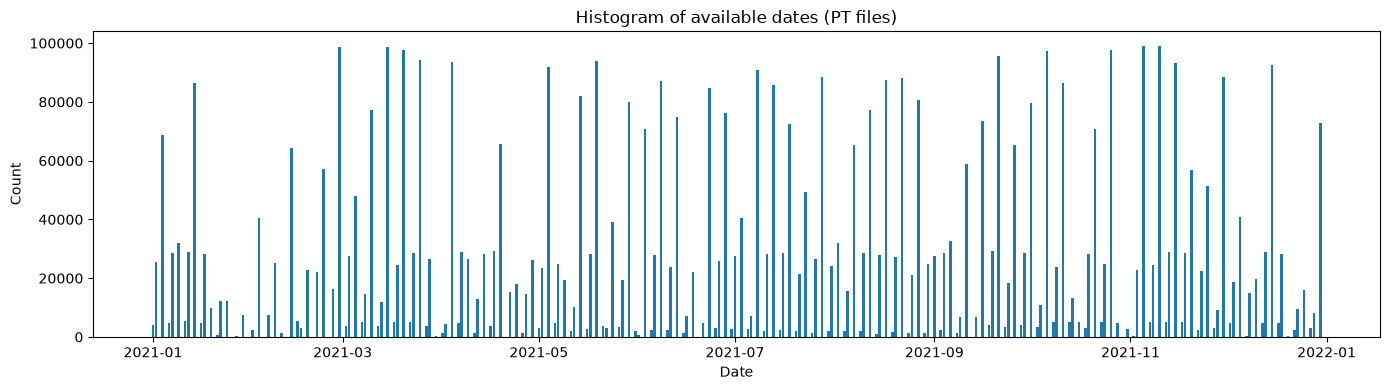

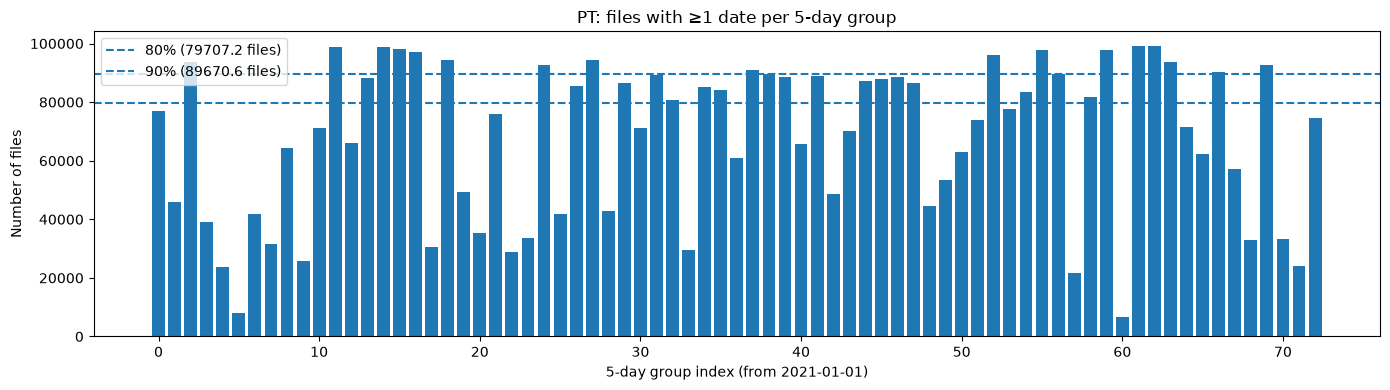

[PT] 5-day, ≥80%: 34 bins kept, 22360/99634 files kept
[PT] 5-day, ≥90%: 17 bins kept, 68455/99634 files kept


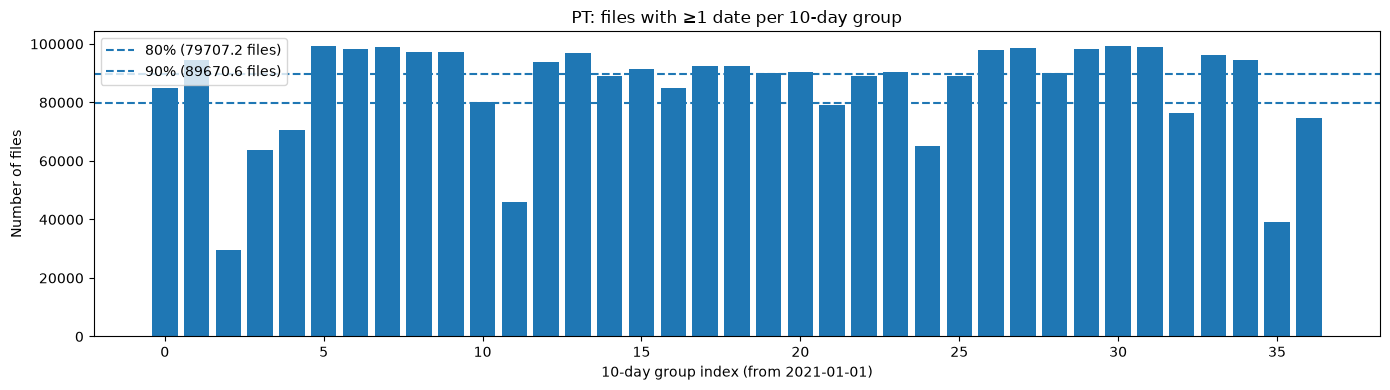

[PT] 10-day, ≥80%: 28 bins kept, 38432/99634 files kept
[PT] 10-day, ≥90%: 22 bins kept, 65790/99634 files kept


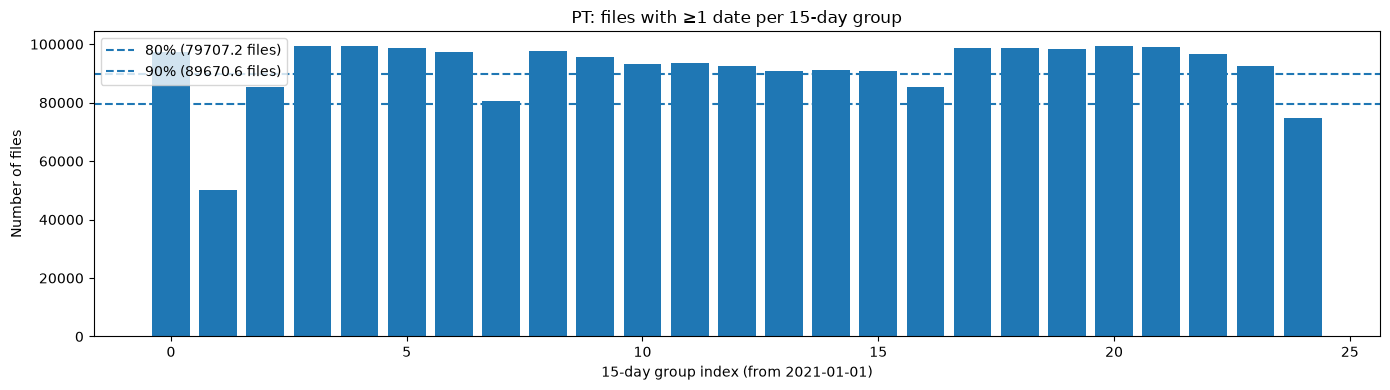

[PT] 15-day, ≥80%: 23 bins kept, 52198/99634 files kept
[PT] 15-day, ≥90%: 20 bins kept, 75084/99634 files kept


In [3]:
pt_dic = summarize_country(f"PT*.npz")

Found 175906 EE files


Reading EE:   0%|          | 0/175906 [00:00<?, ?file/s]

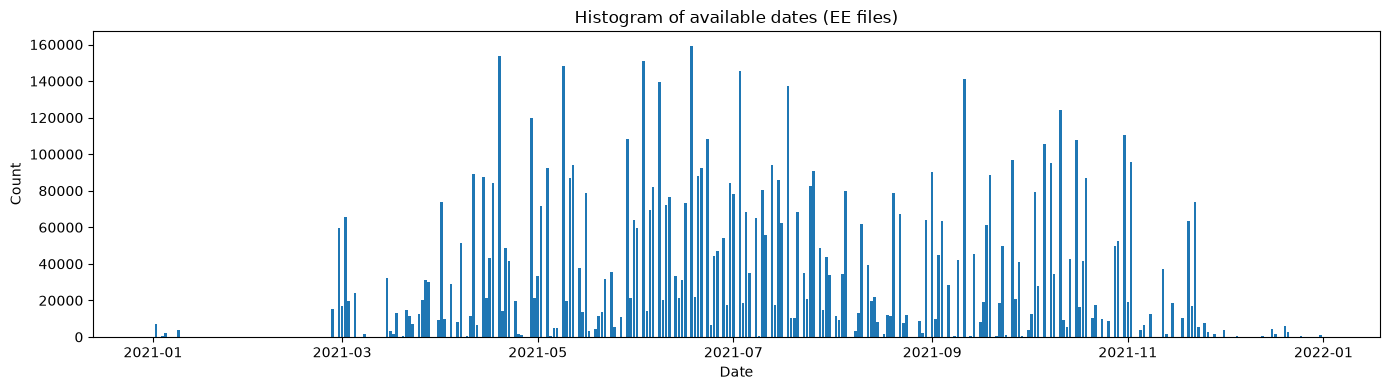

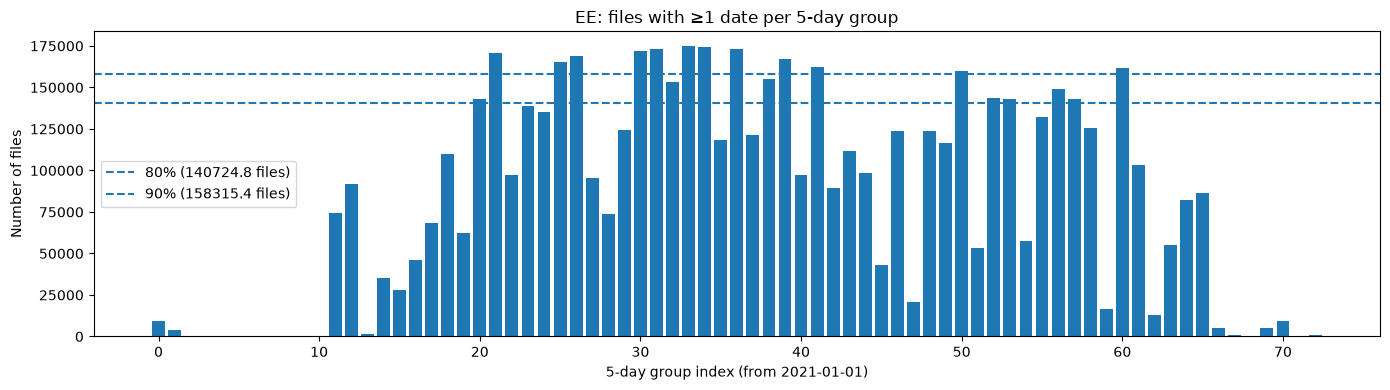

[EE] 5-day, ≥80%: 19 bins kept, 34799/175906 files kept
[EE] 5-day, ≥90%: 12 bins kept, 108412/175906 files kept


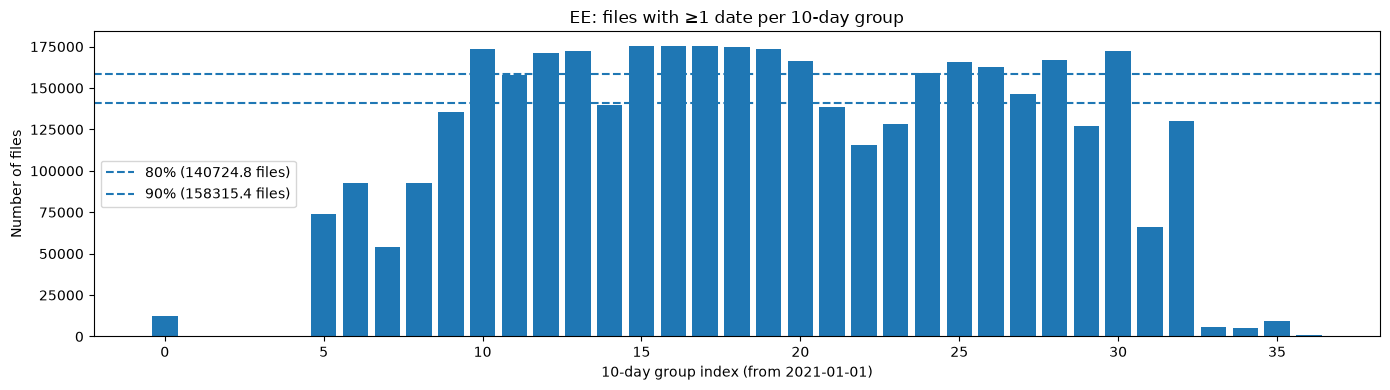

[EE] 10-day, ≥80%: 16 bins kept, 83694/175906 files kept
[EE] 10-day, ≥90%: 14 bins kept, 114571/175906 files kept


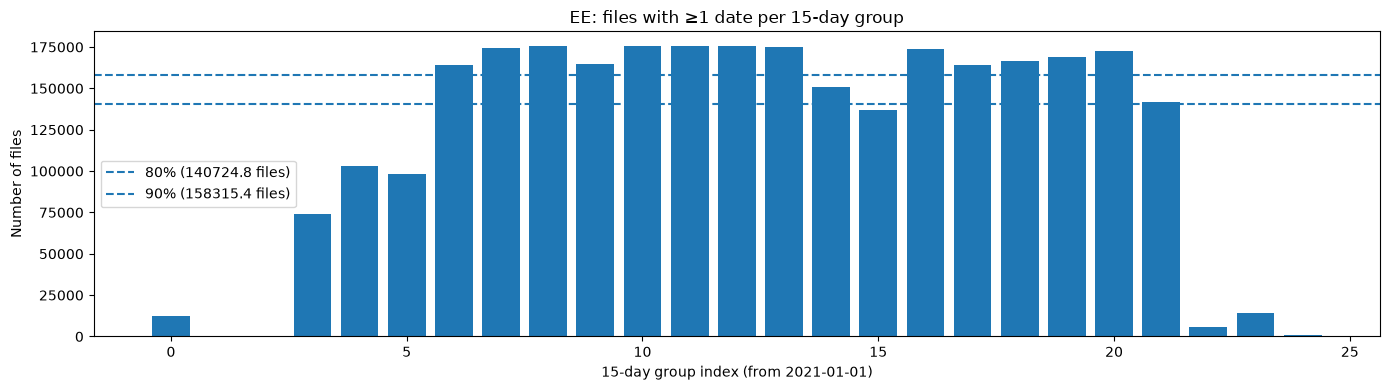

[EE] 15-day, ≥80%: 15 bins kept, 87220/175906 files kept
[EE] 15-day, ≥90%: 13 bins kept, 124711/175906 files kept


In [4]:
ee_dic = summarize_country(f"EE*.npz")

Found 431143 LV files


Reading LV:   0%|          | 0/431143 [00:00<?, ?file/s]

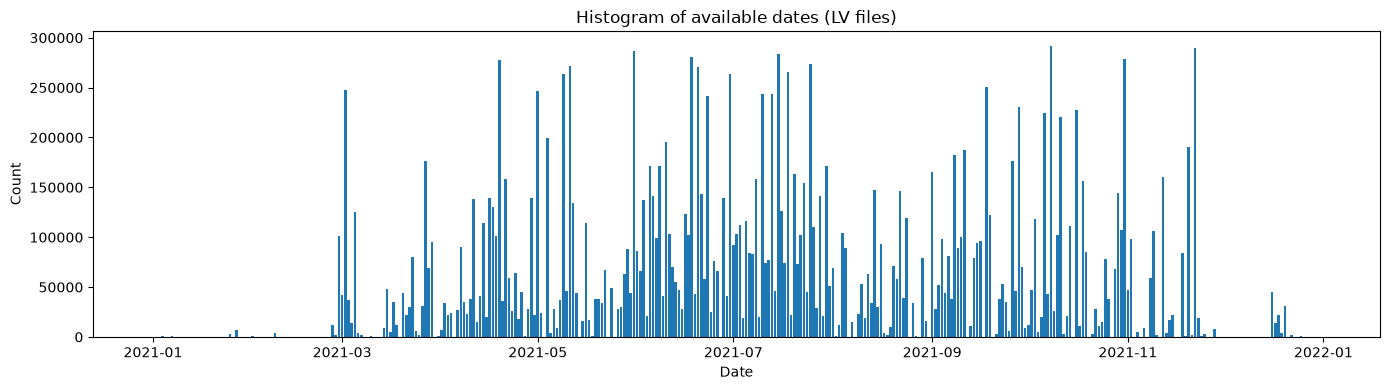

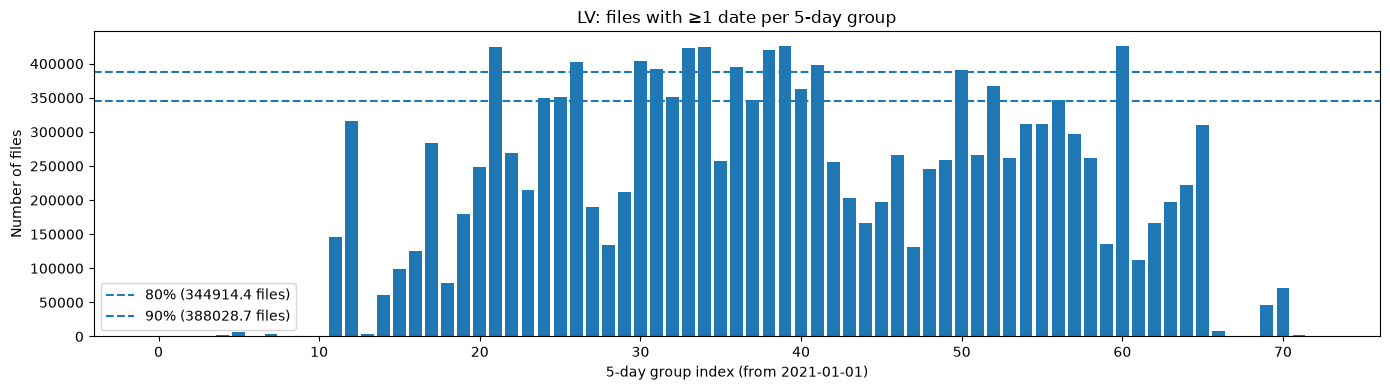

[LV] 5-day, ≥80%: 19 bins kept, 74830/431143 files kept
[LV] 5-day, ≥90%: 12 bins kept, 253618/431143 files kept


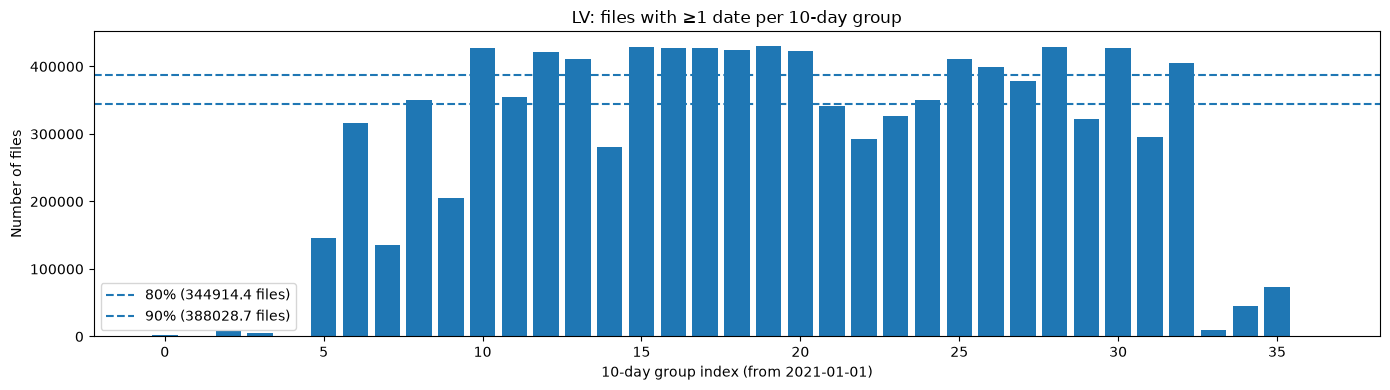

[LV] 10-day, ≥80%: 18 bins kept, 157148/431143 files kept
[LV] 10-day, ≥90%: 14 bins kept, 310283/431143 files kept


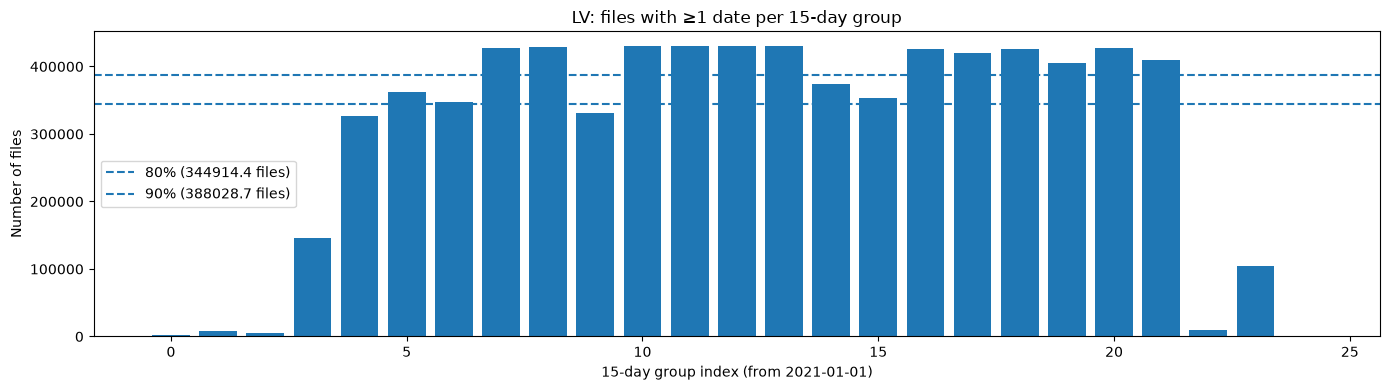

[LV] 15-day, ≥80%: 16 bins kept, 180673/431143 files kept
[LV] 15-day, ≥90%: 12 bins kept, 356929/431143 files kept


In [5]:
lv_dic = summarize_country(f"LV*.npz")